In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/Arthritis_MRI_Project/archive.zip"

print("ZIP file exists:", os.path.exists(zip_path))
print("ZIP path:", zip_path)

ZIP file exists: True
ZIP path: /content/drive/MyDrive/Arthritis_MRI_Project/archive.zip


In [ ]:
import zipfile
import os

extract_path = "/content/arthritis_mri"

if not os.path.exists(extract_path):

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset extracted successfully!")

else:
    print("Dataset is already extracted.")

Dataset extracted successfully!


In [ ]:
dataset_path = "/content/arthritis_mri/Osteoarthritis dataset /auto_test"

print("Dataset folder exists:", os.path.exists(dataset_path))
print("Dataset path:", dataset_path)

Dataset folder exists: True
Dataset path: /content/arthritis_mri/Osteoarthritis dataset /auto_test


In [ ]:
import os

print("Classes and number of images:\n")

for folder in sorted(os.listdir(dataset_path)):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        images = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith(".png")
        ]

        print("Class", folder, ":", len(images), "images")

Classes and number of images:

Class 0 : 604 images
Class 1 : 275 images
Class 2 : 403 images
Class 3 : 200 images
Class 4 : 44 images


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (180, 180)
Batch size: 32


In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 1526 files belonging to 5 classes.
Using 1221 files for training.


In [ ]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale"
)

Found 1526 files belonging to 5 classes.
Using 305 files for validation.


In [ ]:
class_names = train_dataset.class_names

print("Class names:")
print(class_names)

Class names:
['0', '1', '2', '3', '4']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Data pipeline ready.")

Data pipeline ready.


In [ ]:
model = models.Sequential([


    layers.Input(shape=(180, 180, 1)),


    layers.Rescaling(1./255),


    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),


    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),


    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(),

    layers.Flatten(),


    layers.Dense(
        128,
        activation="relu"
    ),


    layers.Dropout(0.5),


    layers.Dense(
        5,
        activation="softmax"
    )
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - accuracy: 0.3677 - loss: 1.4657 - val_accuracy: 0.3541 - val_loss: 1.4553
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.3776 - loss: 1.4243 - val_accuracy: 0.3541 - val_loss: 1.4536
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.4029 - loss: 1.4108 - val_accuracy: 0.3541 - val_loss: 1.4513
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4021 - loss: 1.4138 - val_accuracy: 0.3541 - val_loss: 1.4568
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4046 - loss: 1.4160 - val_accuracy: 0.3541 - val_loss: 1.4576
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4054 - loss: 1.4038 - val_accuracy: 0.3541 - val_loss: 1.4482
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.4070 - loss: 1.4019 - val_accuracy: 0.3541 - val_loss: 1.4430
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.4038 - loss: 1.4055 - val_accuracy: 0.3541 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.3541 - loss: 1.4410
Test Loss: 1.4409836530685425
Test Accuracy: 0.3540983498096466
Test Accuracy (%): 35.40983498096466


In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated.")
print("Number of test images:", len(y_true))

Predictions generated.
Number of test images: 305


In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[108   0   0   0   0]
 [ 58   0   0   0   0]
 [ 81   0   0   0   0]
 [ 48   0   0   0   0]
 [ 10   0   0   0   0]]


In [ ]:
model_path = "/content/osteoarthritis_mri_model.keras"

model.save(model_path)

print("Model saved at:")
print(model_path)

Model saved at:
/content/osteoarthritis_mri_model.keras


In [ ]:
from google.colab import files

files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
test_image_path = "/content/arthritis_mri/Osteoarthritis dataset /auto_test/4/9282257_1.png"

print("Image exists:", os.path.exists(test_image_path))

Image exists: True


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

img = load_img(
    test_image_path,
    target_size=IMG_SIZE,
    color_mode="grayscale"
)

img_array = img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

print("Image prepared for prediction.")
print("Shape:", img_array.shape)

Image prepared for prediction.
Shape: (1, 180, 180, 1)


In [ ]:
prediction = model.predict(img_array)

predicted_class = np.argmax(
    prediction[0]
)

confidence = prediction[0][predicted_class]

print("Predicted class:", class_names[predicted_class])
print("Confidence:", confidence * 100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
Predicted class: 0
Confidence: 35.699196 %


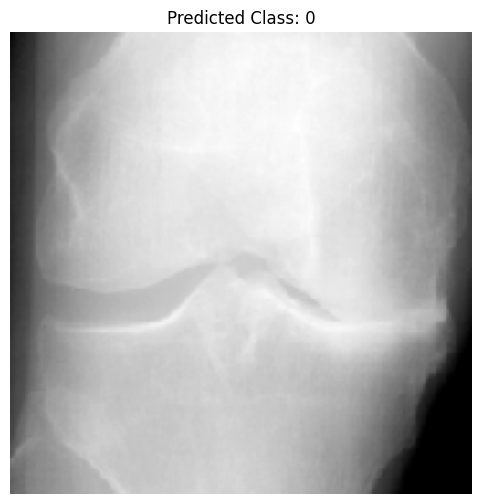

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(
    img,
    cmap="gray"
)

plt.title(
    f"Predicted Class: {class_names[predicted_class]}"
)

plt.axis("off")

plt.show()

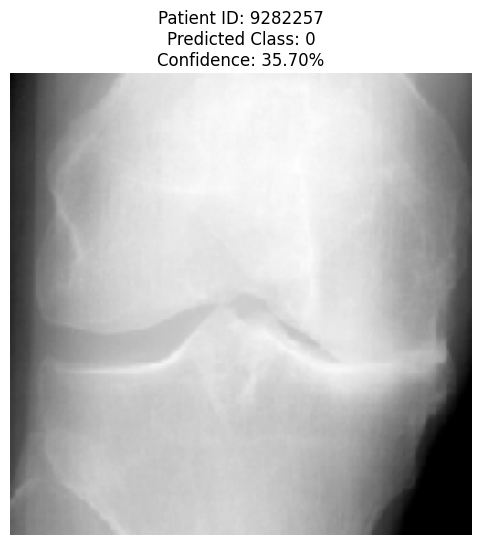

        MRI Predicted RESULT
Patient ID      : 9282257
Image Name      : 9282257_1.png
Predicted Class : 0
Confidence      : 35.70%


In [ ]:
import os
import matplotlib.pyplot as plt


test_image_path = "/content/arthritis_mri/Osteoarthritis dataset /auto_test/4/9282257_1.png"


filename = os.path.basename(test_image_path)

patient_id = filename.split("_")[0]

img = load_img(
    test_image_path,
    target_size=IMG_SIZE,
    color_mode="grayscale"
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)

predicted_class = np.argmax(prediction[0])
confidence = prediction[0][predicted_class] * 100

plt.figure(figsize=(6, 6))

plt.imshow(img, cmap="gray")

plt.title(
    f"Patient ID: {patient_id}\n"
    f"Predicted Class: {class_names[predicted_class]}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()


print("        MRI Predicted RESULT")
print("====================================")
print("Patient ID      :", patient_id)
print("Image Name      :", filename)
print("Predicted Class :", class_names[predicted_class])
print("Confidence      :", f"{confidence:.2f}%")
